# seq2seq 任务实战
- 序列到序列 (sequence-to-sequence, Seq2Seq) 任务，即对于每一个输入序列都会输出一个对应的序列
    - 翻译：将一种语言的文本转换为另一种语言的文本，例如将英文翻译为中文。
    - 文本摘要 (Summarization)：将长文本压缩为短文本，并且还要尽可能保留核心内容。
    - 风格转换 (Style transfer)：将文本转换为另一种书写风格，例如将文言文转换为白话文、将古典英语转换为现代英语；
    - 生成式问答 (Generative question answering)：对于给定的问题，基于上下文生成对应的答案



# 翻译微调任务
- 内容：微调一个 Marian 翻译模型进行汉英翻译，该模型已经基于 Opus 语料对汉英翻译任务进行了预训练，因此可以直接用于翻译。而通过我们的微调，可以进一步提升该模型在特定语料上的性能。
- 数据： translation2019zh 语料作为数据集，它共包含中英文平行语料 520 万对，可以用于训练中英翻译模型。
    - 该语料已经划分好了训练集和验证集，分别包含 516 万和 3.9 万个样本，语料以 json 格式提供，一行是一个中英文对照句子对{"english": "In Italy, there is no real public pressure for a new, fairer tax system.", "chinese": "在意大利，公众不会真的向政府施压，要求实行新的、更公平的税收制度。"}
- 分词注意点:
    - 模型采用源语言的设定来编码文本（对于英翻译模型 opus-mt-zh-en 而言就是中文）
    - 中文分词器默认会对中文进行分词，而英文分词器则会更合理地识别英文 token。
    - 因此，在对英文文本进行编码时，需要使用 text_target 参数，以确保模型能够正确识别英文单词。
- 标签：标签序列就是目标语言的 token ID 序列
- 损失计算：预测标签序列与答案标签序列之间计算损失来调整模型参数
- 同样需要将填充的 pad 字符设置为 -100，以便在使用交叉熵计算序列损失时将它们忽略
- seq2seq 还多一个解码器的输入，即目标语言的 token ID 序列


# 1.准备数据
- translation2019zh 并没有提供测试集，而且使用五百多万条样本进行训练耗时过长，这里我们只抽取训练集中的前 10000条数据，并从中划分出 2000条数据作为验证集，然后将 translation2019zh 中的验证集的前2000条作为测试集：
- 数据预处理：选择 Helsinki-NLP 提供的汉英翻译模型 opus-mt-zh-en 对应的分词器
    - 按 batch 加载数据
    - 将文本转换为模型可以接受的 token IDs
    - 对 token IDs 进行 padding 或 truncation 以确保每个 batch 中样本长度一致
    - 运用分词器同时对源文本和目标文本进行编码

In [49]:
from torch.utils.data import Dataset, random_split
import json

#保护显卡人人有责
max_dataset_size = 10000
train_set_size = 8000
valid_set_size = 2000

class TRANS(Dataset):
    def __init__(self, data_file,max_dataset_size=10000):
        self.data = self.load_data(data_file,max_dataset_size)
    
    def load_data(self, data_file,max_dataset_size):
        Data = {}
        with open(data_file, 'rt', encoding='utf-8') as f:
            for idx, line in enumerate(f):
                if idx >= max_dataset_size:
                    break
                sample = json.loads(line.strip())
                Data[idx] = sample
        return Data
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

data = TRANS('data/translation2019zh/translation2019zh_train.json')
# 随机划分训练集和验证集,避免捕捉到顺序上的信息
train_data, valid_data = random_split(data, [train_set_size, valid_set_size])
# 测试集就200
test_data = TRANS('data/translation2019zh/translation2019zh_valid.json',max_dataset_size=200)


In [16]:


print(f'train set size: {len(train_data)}')
print(f'valid set size: {len(valid_data)}')
print(f'test set size: {len(test_data)}')
print(next(iter(train_data)))

train set size: 8000
valid set size: 2000
test set size: 2000
{'english': 'Smaller organizations, which may not have huge development resources, will gain access to sophisticated, standard-based OSS/BSS APIs.', 'chinese': '而规模较小没有大量开发资源的组织，则可以在结果公布后获取已经比较成熟的，标准化的OSS/BSS API。'}


In [3]:
from transformers import AutoTokenizer

model_checkpoint = "Helsinki-NLP/opus-mt-zh-en"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

d:\software\Anaconda\envs\LLM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\software\Anaconda\envs\LLM\lib\site-packages\transformers\models\marian\tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


默认情况下分词器会采用源语言的设定来编码文本（对于英翻译模型 opus-mt-zh-en 而言就是中文），要编码目标语言则需要使用 text_targets 参数：

In [4]:
#比如取第一条记录，分别抽取中文和英文
zh_sentence = train_data[0]["chinese"]
en_sentence = train_data[0]["english"]
#对于中文 opus-mt-zh-en 模型默认可以对中文进行编码
inputs = tokenizer(zh_sentence)
#对于英文则需要使用 text_target 参数进行编码
targets = tokenizer(text_target=en_sentence)

In [9]:
en_sentence

'During El Niño events, heat is redistributed from deep water to the surface, which raises ocean temperatures and has widespread climatic effects.'

#### 若不使用 text_target 参数，则使用源语言分词器对目标语言进行编码，产生不太好的分词结果：
- 由于中文分词器无法很好地识别英文单词，用它编码英文文本会生成更多的 token

In [ ]:

wrong_targets = tokenizer(en_sentence) 
print(tokenizer.convert_ids_to_tokens(wrong_targets["input_ids"]))
#对比正常编码结果
print(tokenizer.convert_ids_to_tokens(targets["input_ids"]))

['▁D', 'ur', 'ing', '▁El', '▁', 'Ni', 'ñ', 'o', '▁', 'ev', 'ent', 's', ',', '▁he', 'at', '▁is', '▁', 'red', 'ist', 'ri', 'bu', 'ted', '▁from', '▁de', 'ep', '▁', 'wa', 'ter', '▁to', '▁the', '▁s', 'ur', 'f', 'ace', ',', '▁w', 'h', 'ich', '▁', 'ra', 'is', 'es', '▁', 'o', 'ce', 'an', '▁t', 'em', 'per', 'a', 'tu', 'res', '▁and', '▁h', 'as', '▁w', 'ide', 'sp', 're', 'ad', '▁c', 'lim', 'ati', 'c', '▁', 'e', 'ff', 'e', 'c', 'ts', '.', '</s>']
['▁Dur', 'ing', '▁El', '▁Ni', 'ñ', 'o', '▁events', ',', '▁heat', '▁is', '▁redistribute', 'd', '▁from', '▁deep', '▁water', '▁to', '▁the', '▁surface', ',', '▁which', '▁raises', '▁ocean', '▁temperatures', '▁and', '▁has', '▁widespread', '▁climatic', '▁effects', '.', '</s>']


In [5]:
import torch

max_input_length = 128
max_target_length = 128
# 取前四条样本
inputs = [train_data[s_idx]["chinese"] for s_idx in range(4)]
targets = [train_data[s_idx]["english"] for s_idx in range(4)]

inputs

['巴氏毕赤酵母表达体系是近年发展起来的真核表达体系，具有良好的应用前景。',
 '她们从来都不打架，每次我回家的时候，她们都会跑上来亲我的脚趾头。',
 '以统计方法分析所量得含水率数值之准确性与精密性。',
 '此联系独立于血中其他与癌症发展有关的指标。 “Bueno-de-Mesquita说。']


### padding 的逻辑：
- 设置了最大长度为128，因此如果序列长度小于128，会用pad_token_id填充到128长度。
- 需要将填充的 pad 字符设置为 -100，以便在使用交叉熵计算序列损失时将它们忽略
- 该分词模型的eos对应的ids为0，这里通过 tokenizer.eos_token_id 定位其在 token ID 序列中的索引，然后将其之后的 pad 字符设置为 -100。

In [6]:
#padding逻辑演示示例

model_inputs = tokenizer(
    inputs, 
    padding=True, 
    max_length=max_input_length, 
    truncation=True,
    return_tensors="pt"
)
labels = tokenizer(
    text_target=targets, #指定目标语言为英文
    padding=True, 
    max_length=max_target_length, 
    truncation=True,
    return_tensors="pt"
)["input_ids"] # 获得目标语言的 token id 序列

end_token_index = torch.where(labels == tokenizer.eos_token_id)[1]
for idx, end_idx in enumerate(end_token_index):
    labels[idx][end_idx+1:] = -100 # 将目标语言序列中 eos_token_id 后面的 token 设为 -100，用于计算损失时忽略 

In [7]:
  

print('batch_X shape:', {k: v.shape for k, v in model_inputs.items()})
print('batch_y shape:', labels.shape)
print(model_inputs)
print(labels)

batch_X shape: {'input_ids': torch.Size([4, 26]), 'attention_mask': torch.Size([4, 26])}
batch_y shape: torch.Size([4, 34])
{'input_ids': tensor([[11538, 24065, 25027, 35011, 41389,  8808,  6137,  3424,    69,  3016,
            31,   371,  2945,    11,  2974,  2236,  6137,  3424,     2,   744,
          9165,  4106,  9716,     9,     0, 65000],
        [16311, 45454,   155, 35980,     2, 13209,   121,  6079,  2408,     2,
          2929,  8146,  4795, 25147,  5979,  1499,  7160, 50257,  1773,     9,
             0, 65000, 65000, 65000, 65000, 65000],
        [    7,   114,  2158,  1187,  1378,   263,  2061,   785,  9869,  1020,
          2219, 24892,   892,  6159,   364,    65,  8250,  6147,   364,     9,
             0, 65000, 65000, 65000, 65000, 65000],
        [11663,  2046, 31204,  4715,    80,   628,    65, 18325,   371,   970,
          2149,     9,   196, 24289,  1685,   861,    15,  3789,    15,  1506,
          1199,  9865,  4561,   300,     9,     0]]), 'attention_mask': te

### seq2seq使用的是encoder-decoder框架，所以decoder也需要输入
- 需要额外准备 decoder input IDs 作为 Decoder 的输入
- 右移操作：decoder input IDs 是标签序列的移位，在序列的开始位置需要增加一个特殊的“序列起始符”。
- 通过模型自带的 prepare_decoder_input_ids_from_labels 函数来完成
---
### 模型构建直接使用AutoModelForSeq2SeqLM
- 确保输入符合模型的要求
- 直接使用 Transformers 库自带的 AutoModelForSeq2SeqLM 函数来构建模型
    - 因此我们需要将每一个 batch 中的数据处理为该模型可接受的格式：一个包含 'input_ids'、'attention_mask'、'labels' 和 'decoder_input_ids' 键的字典。

In [33]:
#查看模型的输入要求
import inspect
print(inspect.signature(model.forward))

(input_ids: Optional[torch.LongTensor] = None, attention_mask: Optional[torch.Tensor] = None, decoder_input_ids: Optional[torch.LongTensor] = None, decoder_attention_mask: Optional[torch.Tensor] = None, head_mask: Optional[torch.Tensor] = None, decoder_head_mask: Optional[torch.Tensor] = None, cross_attn_head_mask: Optional[torch.Tensor] = None, encoder_outputs: Union[tuple[torch.Tensor], transformers.modeling_outputs.BaseModelOutput, NoneType] = None, past_key_values: Optional[transformers.cache_utils.Cache] = None, inputs_embeds: Optional[torch.FloatTensor] = None, decoder_inputs_embeds: Optional[torch.FloatTensor] = None, labels: Optional[torch.LongTensor] = None, use_cache: Optional[bool] = None, output_attentions: Optional[bool] = None, output_hidden_states: Optional[bool] = None, return_dict: Optional[bool] = None, cache_position: Optional[torch.Tensor] = None) -> transformers.modeling_outputs.Seq2SeqLMOutput


In [8]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoModelForSeq2SeqLM

max_length = 128
batch_size = 32

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)
model = model.to(device)

def collote_fn(batch_samples):
    batch_inputs, batch_targets = [], []
    for sample in batch_samples:
        batch_inputs.append(sample['chinese'])
        batch_targets.append(sample['english'])
    batch_data = tokenizer(
        batch_inputs, 
        text_target=batch_targets, #定义目标序列的语言类型，分词器可以并行地处理源/目标语言
        padding=True, 
        max_length=max_length,
        truncation=True, 
        return_tensors="pt"
    )
    # 为 decoder 准备目标序列的 ids
    batch_data['decoder_input_ids'] = model.prepare_decoder_input_ids_from_labels(batch_data['labels'])
    end_token_index = torch.where(batch_data['labels'] == tokenizer.eos_token_id)[1]
    #padding操作
    for idx, end_idx in enumerate(end_token_index):
        batch_data['labels'][idx][end_idx+1:] = -100
    return batch_data

train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collote_fn)
valid_dataloader = DataLoader(valid_data, batch_size=batch_size, shuffle=False, collate_fn=collote_fn)


Using cuda device


In [9]:
#查看一个batch的数据，确定分词结果
batch = next(iter(train_dataloader))
print(list(batch.keys())) #满足模型的输入要求
print('batch shape:', {k: v.shape for k, v in batch.items()})
print(batch['labels'])#并且填充 token 对应的标签都被设置为 -100
print(batch['decoder_input_ids']) # decoder input IDs 尺寸与标签序列完全相同，且通过向后移位在序列头部添加了特殊的“序列起始符”，对应的ids很大



['input_ids', 'attention_mask', 'labels', 'decoder_input_ids']
batch shape: {'input_ids': torch.Size([32, 42]), 'attention_mask': torch.Size([32, 42]), 'labels': torch.Size([32, 46]), 'decoder_input_ids': torch.Size([32, 46])}
tensor([[11470, 56797,    29,  ...,  -100,  -100,  -100],
        [   78,     7, 33248,  ...,  -100,  -100,  -100],
        [   78,  4373,     4,  ...,  -100,  -100,  -100],
        ...,
        [  264, 28228,     2,  ...,    22,     5,     0],
        [   24,  2125,     4,  ...,  -100,  -100,  -100],
        [ 1727,     2,   211,  ...,  -100,  -100,  -100]])
tensor([[65000, 11470, 56797,  ..., 65000, 65000, 65000],
        [65000,    78,     7,  ..., 65000, 65000, 65000],
        [65000,    78,  4373,  ..., 65000, 65000, 65000],
        ...,
        [65000,   264, 28228,  ..., 47891,    22,     5],
        [65000,    24,  2125,  ..., 65000, 65000, 65000],
        [65000,  1727,     2,  ..., 65000, 65000, 65000]])


labels（监督信号）-100 的含义只有一个：
    ignore_index，告诉 loss：这里不要算。embedding 层 不能接收 -100,labels 是 给 loss 用的。

label:
tensor([[  500,     2,   245,  ...,  -100,  -100,  -100],
        [ 1063,     3,   151,  ...,  -100,  -100,  -100],
        [   26,  1224,  2204,  ...,  -100,  -100,  -100],
        ...,
        [40122,     2,   494,  ...,  -100,  -100,  -100],
        [  140,   204,    12,  ...,  -100,  -100,  -100],
        [   82,    42,   631,  ...,  -100,  -100,  -100]])
- 而decoder_input_ids需要输入到模型中，进行embedding，将其转换为对应的向量表示，用于计算损失函数。必须是合法 token id（≥0 且 < vocab_size）

decoder_input_ids:
tensor([[65000,   500,     2,  ..., 65000, 65000, 65000],
        [65000,  1063,     3,  ..., 65000, 65000, 65000],
        [65000,    26,  1224,  ..., 65000, 65000, 65000],
        ...,
        [65000, 40122,     2,  ..., 65000, 65000, 65000],
        [65000,   140,   204,  ..., 65000, 65000, 65000],
        [65000,    82,    42,  ..., 65000, 65000, 65000]])

- 100变为65000在prepare_decoder_input_ids_from_labels中有两个过程：
decoder_input_ids = shift_right(labels)
decoder_input_ids[decoder_input_ids == -100] = pad_token_id

不用0不用-100的原因是：0有意义，是有效 token（如 <unk>），而-100在embedding找不到对应的向量表示，会导致计算损失函数时出错。



# 2. 模型训练
- 虽然没有定义模型，但还是要了解下模型的结构：
    - 对于输入的序列维度为(batch_size, seq_len) 也就是[32,128]
    - 首先是通过embedding层将输入的token id转换为对应的向量表示，维度为(batch_size, seq_len, hidden_size) [32,128,512]
    - 然后是通过transformer encoder层将向量表示编码为序列表示，维度为(batch_size, seq_len, hidden_size) [32,128,512]
    - 接着是通过linear层将序列表示转换为token id的概率分布，维度为(batch_size, seq_len, vocab_size) [32,128,65000]
    - 最后预测每个向量对应的是词表中的哪个词，即取概率分布中最大的那个词作为预测结果


### 优化模型参数
- 使用 AutoModelForSeq2SeqLM 构造的模型已经封装好了对应的损失函数，并且计算出的损失会直接包含在模型的输出 outputs 中，可以直接通过 outputs.loss 获得
- 前向算损失 → 清零梯度 → 反向算梯度 → 优化器更新权重 → 调度器更新学习率 → 记录损失

In [10]:
#训练循环
from tqdm.auto import tqdm

def train_loop(dataloader, model, optimizer, lr_scheduler, epoch, total_loss):
    progress_bar = tqdm(range(len(dataloader)))
    progress_bar.set_description(f'loss: {0:>7f}')
    finish_batch_num = (epoch-1) * len(dataloader)
    
    model.train()
    for batch, batch_data in enumerate(dataloader, start=1):
        batch_data = batch_data.to(device)
        outputs = model(**batch_data)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward() # 计算梯度
        optimizer.step()
        lr_scheduler.step()

        total_loss += loss.item()
        progress_bar.set_description(f'loss: {total_loss/(finish_batch_num + batch):>7f}')
        progress_bar.update(1)
    return total_loss

### 验证循环
#### 用到一个 BLEU/SacreBLEU 值指标
- 用于度量两个词语序列之间的一致性，但是其并不会衡量语义连贯性或者语法正确性。
- 可以看到，BLEU 值的范围从 0 到 100，越高越好。可以看到，对于一些槽糕的翻译结果，例如包含大量重复词语或者长度过短的预测结果，会计算出非常低的 BLEU 值。

- 由于计算 BLEU 值需要输入分好词的文本，而不同的分词方式会对结果造成影响，因此现在更常用的评估指标是 SacreBLEU，它对分词的过程进行了标准化。SacreBLEU 直接以未分词的文本作为输入，并且对于同一个输入可以接受多个目标作为参考。

- SacreBLEU 默认会采用 mteval-v13a.pl 分词器对文本进行分词，但是它无法处理中文、日文等非拉丁系语言。对于中文就需要设置参数 **tokenize='zh'** 手动使用中文分词器

- 模型 的Decoder 的解码过程进行了封装，我们看不到预测的 token ID，只能看到最终的文本序列。
- 调用模型的 generate() 函数就可以自动地逐个生成预测 token。
    - generate 函数会返回一个形状为 (batch_size, seq_len) 的张量，其中每个元素都是模型生成的 token ID。
    - 再利用tokenizer.decode() 函数将这些 token ID 转换为文本序列。

- 在“验证循环”中，我们首先通过 model.generate() 函数获取预测结果，然后将预测结果和正确标签都处理为 SacreBLEU 接受的文本列表形式（这里我们将标签序列中的 -100 替换为 pad token ID 以便于分词器解码），最后送入到 SacreBLEU 中计算 BLEU 值。

In [11]:
from sacrebleu.metrics import BLEU

predictions = [
    "This plugin lets you translate web pages between several languages automatically."
]
bad_predictions_1 = ["This This This This"]
bad_predictions_2 = ["This plugin"]
references = [
    [
        "This plugin allows you to automatically translate web pages between several languages."
    ]
]

bleu = BLEU()
# bleu = BLEU(tokenize='zh') # 中文需要手动指定分词器
print(bleu.corpus_score(predictions, references).score)
print(bleu.corpus_score(bad_predictions_1, references).score)
print(bleu.corpus_score(bad_predictions_2, references).score)

46.750469682990165
1.683602693167689
0.0


In [45]:
# 我们可以使用分词器的 decode() 函数将这些 token ID 转换为文本序列。
sentence = '我叫张三，我住在苏州。'

sentence_inputs = tokenizer(sentence, return_tensors="pt").to(device)
sentence_generated_tokens = model.generate(
    sentence_inputs["input_ids"],
    attention_mask=sentence_inputs["attention_mask"],
    max_length=128
).cpu().numpy()
print(sentence_generated_tokens)
sentence_generated_text = tokenizer.decode(sentence_generated_tokens[0], skip_special_tokens=True)#skip_special_tokens=True 表示不包含特殊 token
print(sentence_generated_text,sentence)



[[65000  1076  1796    30 42309  6000     2    26  2195    10  9665 53923
      5     0]]
My name is Zhang San, I live in Suzhou. 我叫张三，我住在苏州。


In [ ]:
# 测试循环

from sacrebleu.metrics import BLEU
import numpy as np
bleu = BLEU() #目标序列是英文，所以无需指定分词器

def test_loop(dataloader, model):
    preds, labels = [], []
    
    model.eval()
    for batch_data in tqdm(dataloader):
        batch_data = batch_data.to(device)
        with torch.no_grad():
            generated_tokens = model.generate(
                batch_data["input_ids"],
                attention_mask=batch_data["attention_mask"],
                max_length=max_length,
            ).cpu().numpy() #获得模型生成的token ID并转换为NumPy数组
        label_tokens = batch_data["labels"].cpu().numpy() #将标签也转到CPU并转换为NumPy数组
        
        decoded_preds = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)
        #这里我们将标签序列中的 -100 替换为 pad token ID 以便于分词器解码
        label_tokens = np.where(label_tokens != -100, label_tokens, tokenizer.pad_token_id)
        decoded_labels = tokenizer.batch_decode(label_tokens, skip_special_tokens=True)

        preds += [pred.strip() for pred in decoded_preds]
        labels += [[label.strip()] for label in decoded_labels]

    return bleu.corpus_score(preds, labels).score

### 选择最佳模型进行保存

63

In [52]:
# 在测试前看看未微调的模型效果
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, collate_fn=collote_fn)

test_loop(test_dataloader, model)










100%|██████████| 7/7 [03:05<00:00, 26.48s/it]


15.310245441182444

BLUE值为15.310245441182444

### 正式开始训练
- epoch3个，学习率2e-5
- 还是手动设置学习率下降的模式


In [48]:
from transformers import  get_scheduler
from torch.optim import AdamW

learning_rate = 2e-5
epoch_num = 3

optimizer = AdamW(model.parameters(), lr=learning_rate)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=epoch_num*len(train_dataloader),
)

total_loss = 0.
best_bleu = 0.
for t in range(epoch_num):
    print(f"Epoch {t+1}/{epoch_num}\n-------------------------------")
    total_loss = train_loop(train_dataloader, model, optimizer, lr_scheduler, t+1, total_loss)
    valid_bleu = test_loop(valid_dataloader, model, mode='Valid')
    print(f"BLEU: {valid_bleu:>0.2f}\n")
    if valid_bleu > best_bleu:
        best_bleu = valid_bleu
        print('saving new weights...\n')
        torch.save(model.state_dict(), f'epoch_{t+1}_valid_bleu_{valid_bleu:0.2f}_model_weights.bin')
print("Done!")

Epoch 1/3
-------------------------------


KeyboardInterrupt: 

# 3. 测试模型
- 加载微调后的最佳模型
- 在测试集上评估模型性能
- 将结果保存到json文件中

In [ ]:
import json

model.load_state_dict(torch.load('epoch_1_valid_bleu_53.38_model_weights.bin'))

model.eval()
with torch.no_grad():
    print('evaluating on test set...')
    sources, preds, labels = [], [], []
    for batch_data in tqdm(test_dataloader):
        batch_data = batch_data.to(device)
        generated_tokens = model.generate(
            batch_data["input_ids"],
            attention_mask=batch_data["attention_mask"],
            max_length=max_length,
        ).cpu().numpy()
        label_tokens = batch_data["labels"].cpu().numpy()

        decoded_sources = tokenizer.batch_decode(
            batch_data["input_ids"].cpu().numpy(), 
            skip_special_tokens=True, 
            use_source_tokenizer=True
        )
        decoded_preds = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)
        label_tokens = np.where(label_tokens != -100, label_tokens, tokenizer.pad_token_id)
        decoded_labels = tokenizer.batch_decode(label_tokens, skip_special_tokens=True)

        sources += [source.strip() for source in decoded_sources]
        preds += [pred.strip() for pred in decoded_preds]
        labels += [[label.strip()] for label in decoded_labels]
    bleu_score = bleu.corpus_score(preds, labels).score
    print(f"Test BLEU: {bleu_score:>0.2f}\n")
    results = []
    print('saving predicted results...')
    for source, pred, label in zip(sources, preds, labels):
        results.append({
            "sentence": source, 
            "prediction": pred, 
            "translation": label[0]
        })
    with open('test_data_pred.json', 'wt', encoding='utf-8') as f:
        for exapmle_result in results:
            f.write(json.dumps(exapmle_result, ensure_ascii=False) + '\n')

算力有限，没有真正进行训练，只是在验证集上评估了模型性能

# 关于解码
- 在本文中，我们使用 AutoModelForSeq2SeqLM 模型自带的 generate() 函数，通过柱搜索 (Beam search) 解码出翻译结果（使用模型默认解码参数）。实际上所有 Transformers 库中的生成模型都可以通过 generate() 函数来完成解码，只需要向其传递不同的参数。
- 解码参数：
    - max_length：最大解码长度，默认值为 20。
    - num_beams：柱搜索的 beam 数量，默认值为 5。
    - early_stopping：是否在搜索到第一个 beam 完成解码后立即停止搜索，默认值为 False。

### 不同的搜索算法
- 四种解码方式：
    - 贪心搜索 (Greedy Search)
    - 柱搜索 (Beam search)
    - Top-K 采样 (Top-K sampling)
    - Top-p 采样 (Top-p sampling)。

### 不同搜索算法的对比
- 贪心搜索 (Greedy Search)：
    - 简单直接，每次选择当前概率最高的 token 作为下一个 token。
    - 优点：速度快，解码结果质量高。
    - 缺点：可能会陷入局部最优解，导致翻译结果质量低。
- 柱搜索 (Beam search)：
    - 维护一个大小为 num_beams 的 beam 队列，每次选择当前概率最高的 num_beams 个 token 作为下一个 token。
    - 优点：能够探索更多的翻译路径，提高翻译结果质量。
    - 缺点：计算量较大，解码速度较慢。
- Top-K 采样 (Top-K sampling)：
    - 每次从当前概率最高的 K 个 token 中随机选择一个作为下一个 token。
    - 优点：能够引入随机性，避免陷入局部最优解。
    - 缺点：可能会生成不连贯的翻译结果。
- Top-p 采样 (Top-p sampling)：
    - 每次从当前概率最高的 token 中随机选择一个，直到累计概率超过 p（通常设置为 0.95）。
    - 优点：能够生成连贯的翻译结果，同时引入随机性。
    - 缺点：计算量较大，解码速度较慢。

---
使用distilgpt2演示各类搜索算法的效果


In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("distilgpt2")

# add the EOS token as PAD token to avoid warnings
model = AutoModelForCausalLM.from_pretrained("distilgpt2", pad_token_id=tokenizer.eos_token_id)


d:\software\Anaconda\envs\LLM\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--distilgpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


## 贪心搜索 (Greedy Search)
如下图，在每轮迭代时，即在时间步t，简单地选择概率最高的下一个词作为当前词，
可以看到，从起始词语“The”开始，贪心算法不断地选择概率最高的下一个词直至结束，最后生成词语序列 (“The” “nice” “woman”)，其整体概率为0.4*0.5=0.2,但因此生成的序列往往并不是全局最优的。例如在下图中，词语序列 (“The”, “dog”, “has”) 的概率是0.4*0.9=0.36而这个序列无法通过贪心算法得到
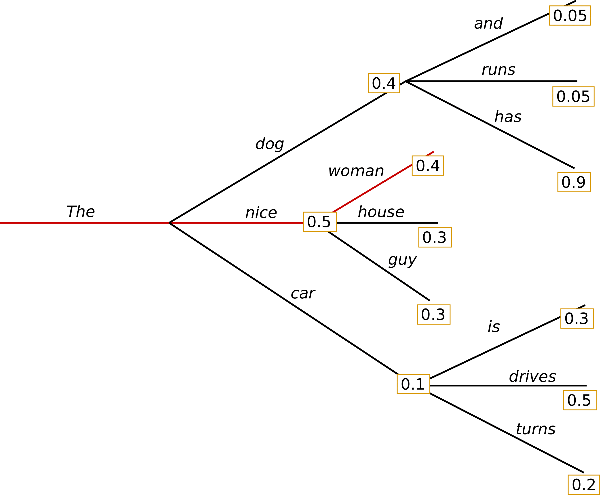


In [ ]:
# 利用贪心搜索生成文本，从起始词语“I enjoy walking with my cute dog”开始，
input_ids = tokenizer.encode('I enjoy walking with my cute dog', return_tensors='pt')

# generate text until the output length (which includes the context length) reaches 50
greedy_output = model.generate(input_ids, max_length=50)

print(tokenizer.decode(greedy_output[0], skip_special_tokens=True))


ValueError: The following `model_kwargs` are not used by the model: ['search_type'] (note: typos in the generate arguments will also show up in this list)

如上，贪心算法陷入了局部最优解，一直在进行循环

---
## 柱搜索 (Beam Search)
柱搜索 (Beam search) 在每个时间步都保留 num_beams 个最可能的词，最终选择整体概率最大的序列作为结果。下图展示了一个 num_beams=2 的例子：
可以看到，在第一个时间步，柱搜索同时保留了概率最大的前 2 个序列：the dog 0.4 和the nice 0.5
在第二个时间步，柱搜索通过计算继续保留概率最大的前 2 个序列 
- 概率为 0.4*0.9=0.36的 (”The“, ”dog“, ”has“) 和
- 概率为 0.4*0.5=0.2的 (”The“, ”nice“, ”woman“)；

最终选择概率最大的序列 (”The“, ”dog“, ”has“) 作为结果。
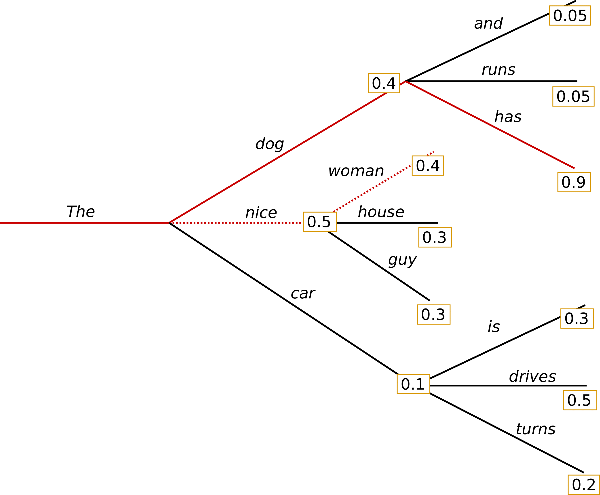

##### 柱搜索虽然通过在每个时间步保留多个分支来缓解贪心算法局部最优解的问题，但是它依然不能保证找到全局最优解。

只需要设置参数:
- num_beams > 1 
- 以及 early_stopping=True，
这样只要所有柱搜索保留的分支都到达休止符 EOS token，生成过程就结束。

In [12]:
# 利用柱搜索生成文本，从起始词语“I enjoy walking with my cute dog”开始，
input_ids = tokenizer.encode('I enjoy walking with my cute dog', return_tensors='pt')

# beam search text until the output length (which includes the context length) reaches 50
beam_output = model.generate(input_ids, max_length=50, num_beams=10, early_stopping=True)

print(tokenizer.decode(beam_output[0], skip_special_tokens=True))


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


I enjoy walking with my cute dog.”
”
”
”
”
”


虽然柱搜索得到的序列更加流畅，但是输出中依然出现了重复片段。
- 最简单的解决方法是引入 n-grams 惩罚:其在每个时间步都手工将那些会产生重复 n-gram 片段的词的概率设为 0。
- 例如，我们额外设置参数 no_repeat_ngram_size=2 就能使生成序列中不会出现重复的 2-gram 片段：

In [13]:
# 利用柱搜索生成文本，从起始词语“I enjoy walking with my cute dog”开始，
input_ids = tokenizer.encode('I enjoy walking with my cute dog', return_tensors='pt')

# beam search text until the output length (which includes the context length) reaches 50
beam_output = model.generate(input_ids, max_length=50, num_beams=10, early_stopping=True, no_repeat_ngram_size=2)

print(tokenizer.decode(beam_output[0], skip_special_tokens=True))


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


I enjoy walking with my cute dog. I’m so happy to be able to share it with you.”


效果明显得到提升

但是！n-grams 也有致命缺点：
n-grams 惩罚虽然能够缓解“重复”问题，却也要谨慎使用。例如对于一篇关于”New York“文章就不能使用 2-gram 惩罚，否则”New York“在全文中就只能出现一次了。

#### 有趣的是，人类语言似乎并不遵循下一个词是最高概率的分布，换句话说，真实的人类语言具有高度的随机性，是不可预测的。
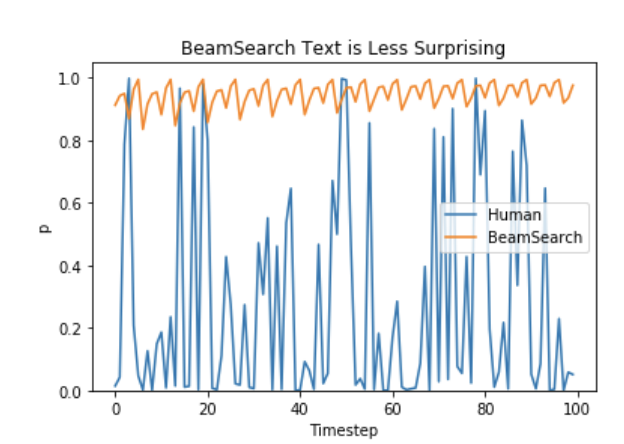

因此，柱搜索更适用于机器翻译或摘要等生成序列长度大致可预测的任务，而在对话生成、故事生成等开放式文本生成任务 (open-ended generation) 上表现不佳。虽然通过 n-gram 或者其他惩罚项可以缓解“重复”问题，但是如何控制”不重复”和“重复”之间的平衡又非常困难。

所以，对于开放式文本生成任务，我们需要引入更多的随机性——这就是采样方法。

## 随机采样(sampling)
采样 (sampling) 最基本的形式就是从当前上下文的条件概率分布中随机地选择一个词作为下一个词

- 在 Transformers 库中，我们只需要在 generate() 中设置 do_sample=True 并且令 top_k=0 禁用 Top-K 采样就可以实现随机采样：


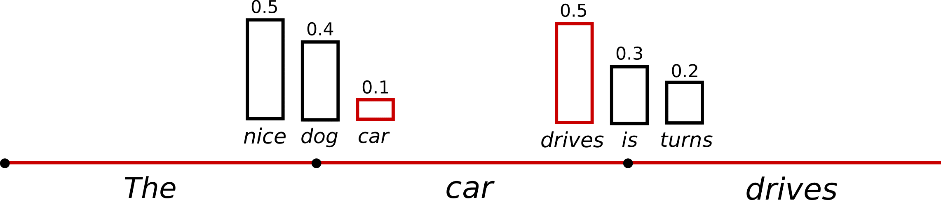

In [ ]:
# 利用随机采样生成文本，从起始词语“I enjoy walking with my cute dog”开始，
input_ids = tokenizer.encode('I enjoy walking with my cute dog', return_tensors='pt')

sampling_output = model.generate(input_ids, max_length=50, do_sample=True, top_k=0)

print(tokenizer.decode(sampling_output[0], skip_special_tokens=True))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


I enjoy walking with my cute dog - rolling up about half a yard from the back of a car and pulling out my baby once again.



At one point im a teacher and she gave me a question about my presence and how I was


可以看到，随机采样生成的文本中，前后片段之间没有明显的连贯性。
- 问题：采样生成文本的通病：模型经常会生成前后不连贯的片段。
- 解决：通过降低 softmax 的温度 (temperature) 使得分布更尖锐，即进一步增加高概率词出现的可能性和降低低概率词出现的可能性。例如对上面的例子应用降温：。
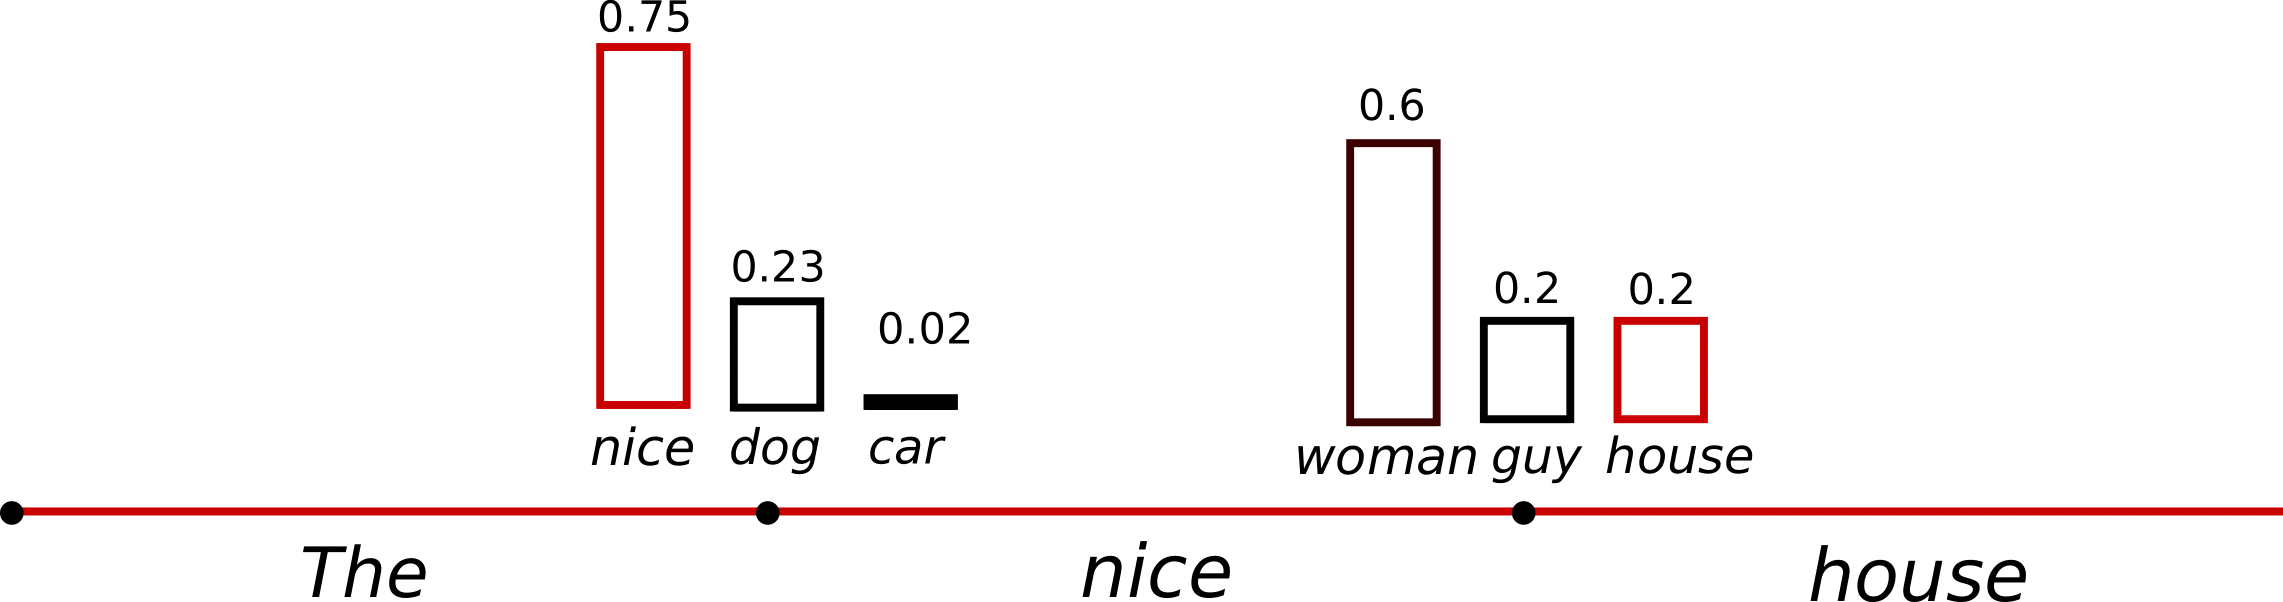


In [18]:
# 利用随机采样生成文本，从起始词语“I enjoy walking with my cute dog”开始，
input_ids = tokenizer.encode('I enjoy walking with my cute dog', return_tensors='pt')

# 降温
sampling_output = model.generate(input_ids, max_length=50, do_sample=True, top_k=0, temperature=0.6)

print(tokenizer.decode(sampling_output[0], skip_special_tokens=True))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


I enjoy walking with my cute dog. I was so happy to see her.

I love seeing a puppy, so happy to see her. I love seeing her. I love seeing her.
Advertisements


可以看到生成的文本更加连贯了。降温操作实际上是在减少分布的随机性，当我们把 temperature 设为 0 时就等同于贪心解码。
所以也是对于随机性和连贯性的平衡。

## top_k 采样
- 类似于 beam search
- Top-K 采样在每个时间步都保留最可能的 K 个词，然后在这 K 个词上重新分配概率质量。
- 可以看到，6 个最可能的词（记为Vtop-k）虽然仅包含第一个时间步中整体概率质量的大约2/3，但是几乎包含了第二个时间步中所有的概率质量。尽管如此，它还是成功地消除了第二步中那些奇怪的候选词（例如“not”、“the”、“small”、“told”）。
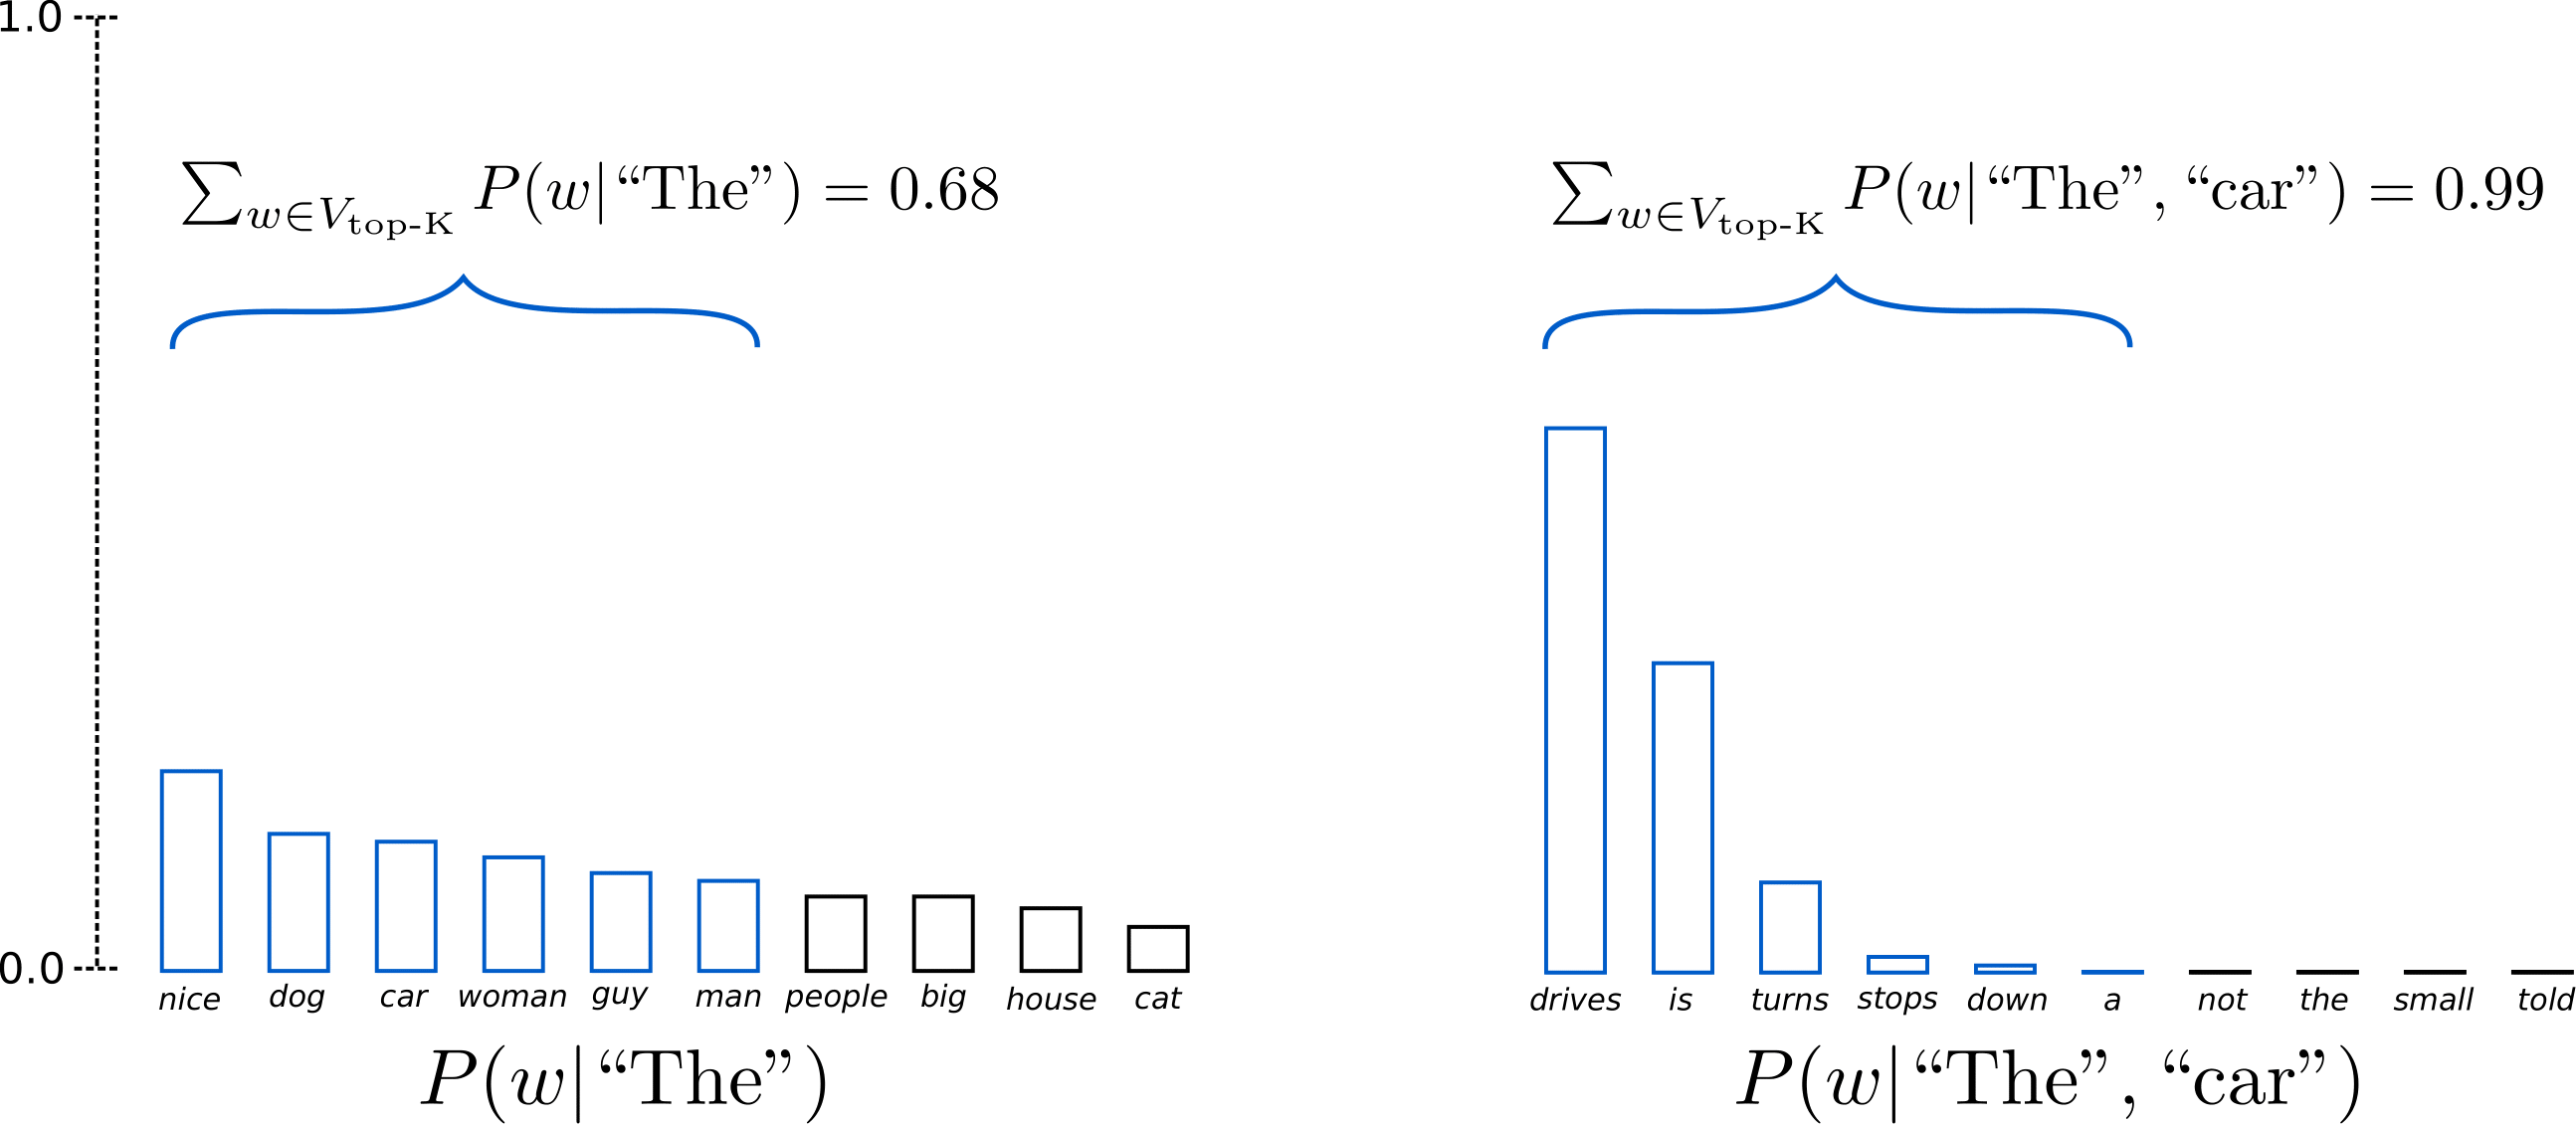

In [20]:
#top-k
sampling_output = model.generate(input_ids, max_length=50, do_sample=True, top_k=10)

print(tokenizer.decode(sampling_output[0], skip_special_tokens=True))


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


I enjoy walking with my cute dog and I have to say this: I love my puppy, he is an amazing person. He has been so amazing to me since he started his life.


It has not been long since I saw my


## Top-p (nucleus) 采样
Top-p 对 Top-K 进行了改进，每次只从累积概率超过 
 的最小的可能词集中进行选择，然后在这组词语中重新分配概率质量。这样，每个时间步的词语集合的大小就可以根据下一个词的条件概率分布动态增加和减少。下图展示了一个 Top-p 采样的例子：
 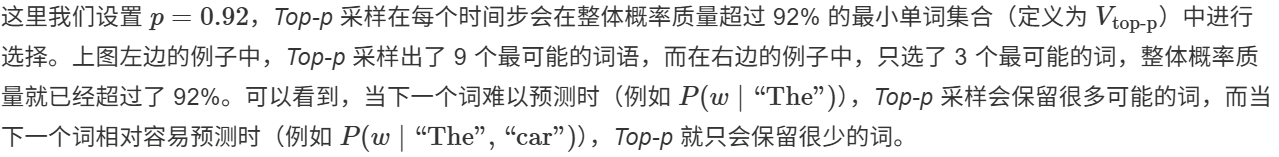

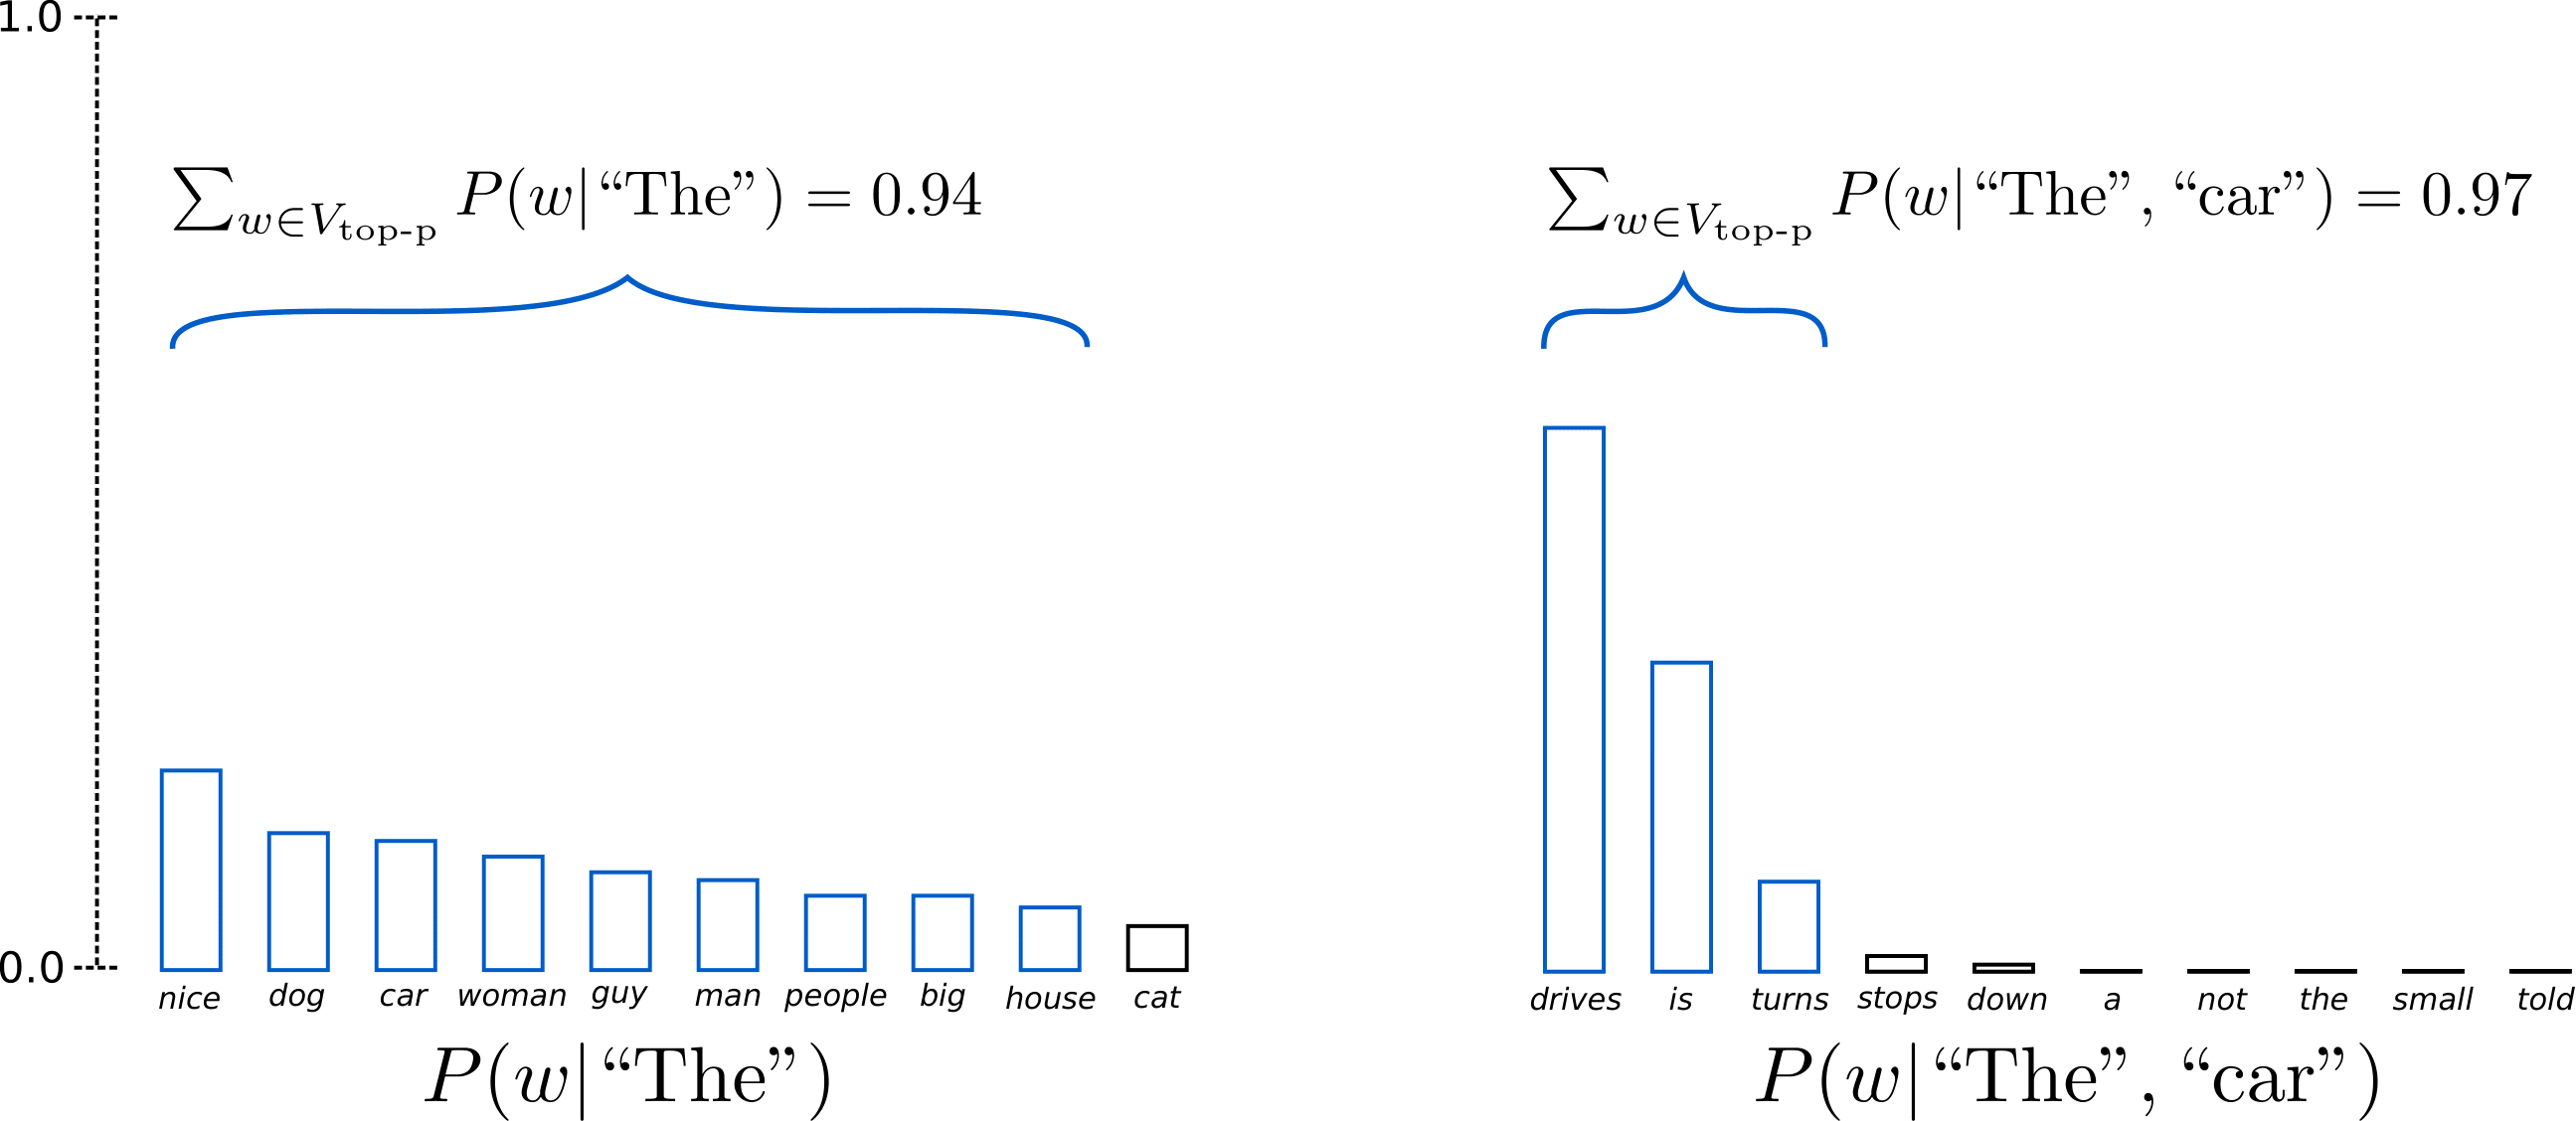

In [23]:
#我们只需要在 generate() 中设置 0 < top_p < 1 就可以激活 Top-p 采样了：
sampling_output = model.generate(input_ids, max_length=50, do_sample=True, top_p=0.92,top_k=0)

print(tokenizer.decode(sampling_output[0], skip_special_tokens=True))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


I enjoy walking with my cute dog and being so curious about it. After sharing this blog, I had no idea what it was doing, and my wife asked about the relevance of the recipe to kick this magical pleasure out of the way, so she


虽然理论上 Top-p 采样比 Top-K 采样更灵活，但是两者在实际应用中都被广泛采用，Top-p 甚至可以与 Top-K 共同工作，这可以在排除低概率词的同时还允许进行一些动态选择。